In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
# from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose

import glob
import os
import csv
import ast

from scipy.stats import chi2_contingency
from math import sqrt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

In [3]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Reading Temp & Precip (6km) 

In [4]:
temp_all = pd.read_csv(DATA_DIR / 'processed_weather_data/temp_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
temp_all['time'] = pd.to_datetime(temp_all['time'])

precip_all = pd.read_csv(DATA_DIR / 'processed_weather_data/precip_all_years_6km_buffer.csv').drop(columns = ['Unnamed: 0'])
precip_all['time'] = pd.to_datetime(precip_all['time'])

### Wind (6km) 

In [5]:
hourly_wind_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_wind_avg_6km.csv').drop(columns=['Unnamed: 0'])
hourly_wind_df['Timestamp'] = pd.to_datetime(hourly_wind_df['Timestamp'])
hourly_wind_df = hourly_wind_df.rename(columns = {'Timestamp':'time'})
hourly_wind_df['Date'] = hourly_wind_df['time'].dt.date

### Lightning (6km) 

In [6]:
hourly_lightning_df = pd.read_csv(DATA_DIR / 'processed_weather_data/ea_hourly_lightning_avg_6km_buffer_aligned.csv').drop(columns=['Unnamed: 0'])
hourly_lightning_df['Timestamp'] = pd.to_datetime(hourly_lightning_df['Timestamp'])
hourly_lightning_df = hourly_lightning_df.rename(columns = {'Timestamp':'time'})
hourly_lightning_df['Date'] = hourly_lightning_df['time'].dt.date

### Extreme Definitions 

### Temp 

In [7]:
# temp_all['Temp'].quantile(0.95)

In [8]:
temp_all['Date'] = temp_all['time'].dt.floor('D')

# Hot hour flag
temp_all['Hot_Hour'] = temp_all['Temp'] > 32

# Group by EA and Date, and count Hot_Hour sum
daily_hot_hours = (
    temp_all.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Hot_Hour': 'sum'})
)

daily_hot_hours = daily_hot_hours.rename(columns={'Hot_Hour': 'Num_Hot_Hours'})

### Precip 

In [9]:
precip_all['Date'] = precip_all['time'].dt.floor('D')  

# Group by EA and Date, sum Precip
daily_precip = (
    precip_all.groupby(['ea_code9ch', 'Date'], as_index=False)
      .agg({'Precip': 'sum'})
)

### Wind 

In [10]:
# Windy hour flag
hourly_wind_df['Windy_Hour'] = hourly_wind_df['Wind Gusts (m/s)'] > 5.93

# Group by EA and Date, and count Windy_Hour sum
daily_windy_hours = (
    hourly_wind_df.groupby(['ea_code9ch', 'Date'], as_index=False)
            .agg({'Windy_Hour': 'sum'})
)

daily_windy_hours = daily_windy_hours.rename(columns={'Windy_Hour': 'Num_Windy_Hours'})

### Lightning 

In [11]:
daily_lightning_per_ea = hourly_lightning_df.groupby(['ea_code9ch', 'Date'])['Lightning Events'].sum().reset_index()

## Percentiles 

In [12]:
### 90th pct 
hot_hrs_90_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.90)
temp_90_thresh = temp_all['Temp'].quantile(0.90)

precip_90_thresh = daily_precip['Precip'].quantile(0.90)
lightning_90_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.90)

windy_hrs_90_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.90)
wind_90_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.90)


### 95th pct 

hot_hrs_95_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.95)
temp_95_thresh = temp_all['Temp'].quantile(0.95)
precip_95_thresh = daily_precip['Precip'].quantile(0.95)
lightning_95_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.95)
windy_hrs_95_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.95)
wind_95_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.95)

### 99th pct 
hot_hrs_99_thresh = daily_hot_hours['Num_Hot_Hours'].quantile(0.99)
temp_99_thresh = temp_all['Temp'].quantile(0.99)
precip_99_thresh = daily_precip['Precip'].quantile(0.99)
lightning_99_thresh = daily_lightning_per_ea['Lightning Events'].quantile(0.99)
windy_hrs_99_thresh = daily_windy_hours['Num_Windy_Hours'].quantile(0.99)
wind_99_thresh = hourly_wind_df['Wind Gusts (m/s)'].quantile(0.99)

#### Dictionary for percentiles 

In [13]:
# Percentile Threshold dictionaries 
temp_thresh_dict = {
    '90': temp_90_thresh.round(2),
    '95': temp_95_thresh.round(2),
    '99': temp_99_thresh.round(2)
}

hot_hrs_thresh_dict = {
    '90': hot_hrs_90_thresh.round(2),
    '95': hot_hrs_95_thresh.round(2),
    '99': hot_hrs_99_thresh.round(2)
}

precip_thresh_dict = {
    '90': precip_90_thresh.round(2),
    '95': precip_95_thresh.round(2),
    '99': precip_99_thresh.round(2)
}

wind_thresh_dict = {
    '90': wind_90_thresh.round(2),
    '95': wind_95_thresh.round(2),
    '99': wind_99_thresh.round(2)
}

windy_hrs_thresh_dict = {
    '90': windy_hrs_90_thresh.round(2),
    '95': windy_hrs_95_thresh.round(2),
    '99': windy_hrs_99_thresh.round(2)
}

lightning_thresh_dict = {
    '90': 1,   # at least 1 lightning strike 
    '95': lightning_95_thresh.round(2),
    '99': lightning_99_thresh.round(2)
}

### Read EAs and CESI level 

### `rev_1`

In [14]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas_rev1.csv').drop(columns = ['Unnamed: 0'])

In [15]:
eas_n_cesi_level

,ea_code9ch,cesi_level
0,30200002,Low
1,30200012,Low
2,30200013,Low
3,30200014,Low
4,30200015,Low
...,...,...
209,31300291,High
210,31300310,Low
211,31300328,Low
212,31300407,Low


### EA Names mapped  

In [16]:
ea_names_mapped = pd.read_csv(DATA_DIR / 'miscellaneous/ea_names_mapped.csv')

ea_names_mapped = ea_names_mapped[['ea_code9ch', 'LOC_NAME', 'BASE_NAM', 'geometry']]

### EAs n Sites  (6km) 

In [17]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

In [18]:
# merged_eas_sites['ea_code9ch'].nunique()

In [19]:
filtered_eas_sites_copy = merged_eas_sites

In [20]:
# EA -> 30200014, 30500020 

In [21]:
def prepare_hourly_weather_df_TPLW(
    ea_row, 
    temp_df, 
    precip_df, 
    lightning_df, 
    wind_df, 
):
    ea = ea_row['ea_code9ch']
    site_list = [int(s) for s in ea_row['Intersecting_Sites']]
    all_sites_dfs = []

    for site_id in site_list:
        # --- Temperature ---
        temp_filt = (
            temp_df[temp_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            .copy()
        )
        if 'Hot_Hour' in temp_filt.columns:
            temp_filt = temp_filt.drop(columns=['Hot_Hour'])
        temp_filt['time'] = pd.to_datetime(temp_filt['time'])

        # --- Precipitation ---
        precip_filt = (
            precip_df[precip_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Precip']]
        )
        precip_filt['time'] = pd.to_datetime(precip_filt['time'])

        # Merge temp + precip
        merged = temp_filt.merge(precip_filt, on='time', how='outer')

        # --- Lightning ---
        lightning_filt = (
            lightning_df[lightning_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Lightning Events']]
        )
        merged = merged.merge(lightning_filt, on='time', how='outer')
        merged['Lightning Events'] = merged['Lightning Events'].fillna(0)

        # --- Wind ---
        wind_filt = (
            wind_df[wind_df['ea_code9ch'] == ea]
            .drop(columns=['geometry'], errors='ignore')
            [['time', 'Wind Gusts (m/s)']]
        )
        merged = merged.merge(wind_filt, on='time', how='inner')

        # Add site_id
        merged['site_id'] = site_id

        all_sites_dfs.append(merged)

    # Concatenate all sites
    df_all = pd.concat(all_sites_dfs, ignore_index=True)

    # Aggregate by timestamp 
    agg_dict = {
        'Temp': 'mean',  # average across sites
        'Precip': 'mean',
        'Lightning Events': 'mean',
        'Wind Gusts (m/s)': 'mean',
        'site_id': lambda x: ','.join(map(str, x))  # list all contributing sites
    }

    df_agg = df_all.groupby('time', as_index=False).agg(agg_dict)

    # Add EA code
    df_agg['ea_code9ch'] = ea

    # Optional: reorder columns
    df_agg = df_agg[
        ['time', 'ea_code9ch', 'site_id', 'Temp', 'Precip', 
         'Lightning Events', 'Wind Gusts (m/s)']
    ]

    return df_agg

## Remove sites with > `10%` missing data & less than 24 months 

In [22]:
sites_to_omit = pd.read_csv(DATA_DIR / 'miscellaneous/complete_site_removal_df.csv')['site_id'].to_list()

### Resample hourly weather data -> Daily 

In [23]:
filtered_eas_sites_copy_r1 = merged_eas_sites.copy()

In [24]:
# Main loop
results = []

for _, row in filtered_eas_sites_copy_r1.iterrows():
    merged_hourly = prepare_hourly_weather_df_TPLW(
        row, 
        temp_all, 
        precip_all, 
        hourly_lightning_df, 
        hourly_wind_df, 
    )
    if merged_hourly is not None:
        results.append(merged_hourly)

merged_hourly_data_global = pd.concat(results, ignore_index=True)

In [25]:
merged_hourly_data_global = merged_hourly_data_global.loc[
    ~merged_hourly_data_global['site_id'].isin(sites_to_omit)
]

In [26]:
### Filter 214 EAs 

tplw_eas = pd.read_csv(DATA_DIR / 'miscellaneous/unique_ea_codes_TPLW.csv')

list_EAs = tplw_eas['ea_code9ch'].unique().tolist()

hourly_global_test = merged_hourly_data_global[merged_hourly_data_global['ea_code9ch'].isin(list_EAs)].reset_index(drop=True)

In [27]:
hourly_global_test['ea_code9ch'].nunique()

214

In [28]:
# hourly_global_test

In [29]:
# 1. Convert to string (just in case)
hourly_global_test['site_id'] = hourly_global_test['site_id'].astype(str)

# 2. Split into list
hourly_global_test['site_id'] = hourly_global_test['site_id'].str.split(',')

# 3. Explode into separate rows
hourly_global_test = hourly_global_test.explode('site_id')

# 4. Clean up (remove spaces + convert to int)
hourly_global_test['site_id'] = hourly_global_test['site_id'].str.strip().astype(int)

### Select percentile, lag, saidi_threshold, agg_method 

In [30]:
percentile = '95'
selected_lags = [0]
saidi_threshold = 0
agg_method = 'mean'

## Daily Resampling 

### Temp 

In [31]:
def compute_hot_flags_daily(
    df,
    temp_thresh=31.257,
    min_hot_hours=4
):
    import pandas as pd

    df = df.copy()

    # Ensure datetime
    df['Date'] = df['time'].dt.date

    # Hot hour flag
    df['Hot_hour'] = df['Temp'] >= temp_thresh

    # Aggregate to daily
    daily_df = (
        df.groupby(['ea_code9ch', 'site_id', 'Date'])
          .agg(
              Hot_hour_count=('Hot_hour', 'sum'),
              mean_temp=('Temp', 'mean'),
              max_temp=('Temp', 'max')
          )
          .reset_index()
    )

    # Hot day flag
    daily_df['Hot_day'] = daily_df['Hot_hour_count'] >= min_hot_hours

    return daily_df

In [32]:
processed_temp = compute_hot_flags_daily(
    
    hourly_global_test,
    
    temp_thresh = temp_thresh_dict[percentile],
    min_hot_hours = hot_hrs_thresh_dict[percentile],    

)

### PWL 

In [33]:
def compute_pwl_flags_daily(
    df,
    precip_thresh=10.0,
    lightning_thresh=5,
    wind_thresh=None,
    min_wind_hours=4
):
    df = df.copy()

    # Date
    df['Date'] = df['time'].dt.date

    # ---------------- WIND ----------------
    df['Wind_hour'] = df['Wind Gusts (m/s)'] >= wind_thresh

    wind_daily = (
        df.groupby(['ea_code9ch', 'site_id', 'Date'])
          .agg(Wind_hour_count=('Wind_hour', 'sum'))
          .reset_index()
    )
    wind_daily['Wind_day'] = wind_daily['Wind_hour_count'] >= min_wind_hours

    # ---------------- PRECIP ----------------
    precip_daily = (
        df.groupby(['ea_code9ch', 'site_id', 'Date'])
          .agg(Precip_sum=('Precip', 'sum'))
          .reset_index()
    )
    precip_daily['Precip_day'] = precip_daily['Precip_sum'] >= precip_thresh

    # ---------------- LIGHTNING ----------------
    lightning_daily = (
        df.groupby(['ea_code9ch', 'site_id', 'Date'])
          .agg(Lightning_sum=('Lightning Events', 'sum'))
          .reset_index()
    )
    lightning_daily['Lightning_day'] = lightning_daily['Lightning_sum'] >= lightning_thresh

    # ---------------- MERGE ALL ----------------
    daily_df = wind_daily.merge(
        precip_daily, on=['ea_code9ch', 'site_id', 'Date'], how='outer'
    ).merge(
        lightning_daily, on=['ea_code9ch', 'site_id', 'Date'], how='outer'
    )

    # Fill NaNs
    daily_df[['Wind_day','Precip_day','Lightning_day']] = (
        daily_df[['Wind_day','Precip_day','Lightning_day']].fillna(False)
    )

    # ---------------- COMBINED EVENTS ----------------
    daily_df['PL_day'] = daily_df['Precip_day'] & daily_df['Lightning_day']

    daily_df['PWL_day'] = (
        daily_df['Precip_day'] &
        daily_df['Wind_day'] &
        daily_df['Lightning_day']
    )

    return daily_df

In [34]:
processed_pwl = compute_pwl_flags_daily(
    
    hourly_global_test,
    
    precip_thresh = precip_thresh_dict[percentile],           # Min total precipitation in a day for Precip Day
    lightning_thresh = lightning_thresh_dict[percentile],   
    
    wind_thresh = wind_thresh_dict[percentile],
    min_wind_hours = windy_hrs_thresh_dict[percentile],    
)

### Combined Weather Df  

In [35]:
combined_daily_weather = processed_pwl.merge(processed_temp, on = ['ea_code9ch', 'site_id', 'Date'])

combined_daily_weather = combined_daily_weather[['ea_code9ch', 'site_id', 'Date', 
                        'Hot_hour_count', 'Hot_day', 
                        'Wind_hour_count', 'Wind_day',
                        'Precip_sum', 'Precip_day', 
                        'Lightning_sum', 'Lightning_day', 
                        'PL_day', 'PWL_day']]

combined_daily_weather['Date'] = pd.to_datetime(combined_daily_weather['Date'])

In [36]:
combined_daily_weather.head()

,ea_code9ch,site_id,Date,Hot_hour_count,Hot_day,Wind_hour_count,Wind_day,Precip_sum,Precip_day,Lightning_sum,Lightning_day,PL_day,PWL_day
0,30200002,456,2022-01-01,0,False,0,False,0.000000,False,0.0,False,False,False
1,30200002,456,2022-01-02,0,False,0,False,4.477796,False,0.0,False,False,False
2,30200002,456,2022-01-03,3,False,0,False,0.162920,False,0.0,False,False,False
3,30200002,456,2022-01-04,0,False,0,False,0.041221,False,0.0,False,False,False
4,30200002,456,2022-01-05,0,False,0,False,0.016973,False,0.0,False,False,False


## read SAIDI data  

In [37]:
# read data 
daily_saidi = pd.read_csv(DATA_DIR / 'SAIDI_SAIFI/SAIDI_Daily_Site Id - 31_03_2016 to 31_03_2026.csv')

# Convert from milliseconds to datetime
daily_saidi['Date'] = pd.to_datetime(daily_saidi['time'], unit='ms')

# Extract year
daily_saidi['year'] = daily_saidi['Date'].dt.year

# Filter for 2022 and 2023
daily_saidi = daily_saidi[daily_saidi['year'].isin([2022, 2023])].reset_index(drop=True)

### Prep data for Regression 

In [38]:
combined_saidi_weather = combined_daily_weather.merge(daily_saidi, on = ['Date', 'site_id'])

combined_saidi_weather = combined_saidi_weather[['ea_code9ch', 'site_id', 'Date', 'SAIDI', 
                        'Hot_hour_count', 'Hot_day',
                        'Wind_hour_count', 'Wind_day', 
                        'Precip_sum', 'Precip_day',
                       'Lightning_sum', 'Lightning_day', 
                        'PL_day', 'PWL_day']]

## add Month and Season 
combined_saidi_weather['Month'] = combined_saidi_weather['Date'].dt.month
combined_saidi_weather['season'] = np.where(combined_saidi_weather['Month'].isin([12, 1, 2, 3]),'dry', np.where(combined_saidi_weather['Month'] == 8, 'transition', 'rainy'))

In [39]:
### rename column names 

In [40]:
combined_saidi_weather = combined_saidi_weather.rename(columns = {
    'Hot_day':'T', 
    'Precip_day':'P', 
    'Lightning_day':'L', 
    'Wind_day':'W'
})

In [41]:
combined_saidi_weather.head()

,ea_code9ch,site_id,Date,SAIDI,Hot_hour_count,T,Wind_hour_count,W,Precip_sum,P,Lightning_sum,L,PL_day,PWL_day,Month,season
0,30200002,456,2022-01-01,0.0,0,False,0,False,0.000000,False,0.0,False,False,False,1,dry
1,30200002,456,2022-01-02,0.0,0,False,0,False,4.477796,False,0.0,False,False,False,1,dry
2,30200002,456,2022-01-03,0.0,3,False,0,False,0.162920,False,0.0,False,False,False,1,dry
3,30200002,456,2022-01-04,0.0,0,False,0,False,0.041221,False,0.0,False,False,False,1,dry
4,30200002,456,2022-01-05,0.0,0,False,0,False,0.016973,False,0.0,False,False,False,1,dry


### Stats df for later usage 

In [42]:
combined_saidi_weather_stats = combined_saidi_weather[['ea_code9ch', 'T', 'W', 'P', 'L', 'Month']]

combined_saidi_weather_stats = combined_saidi_weather_stats.copy()

combined_saidi_weather_stats['PW']  = combined_saidi_weather_stats['P'] & combined_saidi_weather_stats['W']
combined_saidi_weather_stats['PL']  = combined_saidi_weather_stats['P'] & combined_saidi_weather_stats['L']
combined_saidi_weather_stats['WL']  = combined_saidi_weather_stats['W'] & combined_saidi_weather_stats['L']
combined_saidi_weather_stats['PWL'] = combined_saidi_weather_stats['P'] & combined_saidi_weather_stats['W'] & combined_saidi_weather_stats['L']

combined_saidi_weather_stats_df = (
    combined_saidi_weather_stats
    .groupby('ea_code9ch')[['T', 'P', 'L', 'W', 'PW', 'PL', 'WL', 'PWL']]
    .sum()
    .reset_index()
)

In [43]:
combined_saidi_weather_stats_df.head()

,ea_code9ch,T,P,L,W,PW,PL,WL,PWL
0,30200002,50,33,23,27,2,13,0,0
1,30200012,48,32,37,27,1,17,1,1
2,30200013,42,32,13,26,1,10,1,1
3,30200014,35,31,19,28,2,11,2,2
4,30200015,127,90,131,80,6,45,6,6


In [44]:
# combined_saidi_weather_stats_df.to_csv('combined_saidi_weather_stats_df.csv')

### Aggregate combined_saidi_weather per EA first 

In [45]:
import numpy as np
import pandas as pd

def aggregate_saidi_to_ea(
    df,
    ea_col='ea_code9ch',
    site_col='site_id',
    date_col='Date',
    saidi_col='SAIDI',
    saidi_agg='mean'
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Choose aggregation for SAIDI
    valid_aggs = ['mean', 'median', 'max']
    if saidi_agg not in valid_aggs:
        raise ValueError(f"saidi_agg must be one of {valid_aggs}")

    # Columns that should be constant within EA-date
    weather_cols = [
        'Hot_hour_count', 'T',
        'Wind_hour_count', 'W',
        'Precip_sum', 'P',
        'Lightning_sum', 'L',
        'PL_day', 'PWL_day',
        'Month', 'season'
    ]

    # Check available columns
    weather_cols = [c for c in weather_cols if c in df.columns]

    agg_dict = {saidi_col: saidi_agg}
    agg_dict.update({col: 'first' for col in weather_cols})

    # Count sites per EA-date too, useful for diagnostics
    site_counts = (
        df.groupby([ea_col, date_col])[site_col]
        .nunique()
        .rename('n_sites')
        .reset_index()
    )

    df_ea = (
        df.groupby([ea_col, date_col], as_index=False)
        .agg(agg_dict)
        .merge(site_counts, on=[ea_col, date_col], how='left')
    )

    return df_ea

## *** Finding the EAs with significant EW <-> SAIDI relationship 

### Functions 

#### diagnostics function 

In [46]:
### new col names 

In [47]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations

def diagnose_separation_issues(
    df,
    lags,
    base_cols=None,
    id_col='ea_code9ch',
    date_col='Date',
    outcome_col='SAIDI',
    saidi_threshold=0,
    control_months=False,
    coef_threshold=10
):
    df_model = df.copy()
    df_model[date_col] = pd.to_datetime(df_model[date_col])
    df_model = df_model.sort_values([id_col, date_col])

    # Create binary outage variable
    if saidi_threshold > 0:
        df_model['outage'] = (df_model[outcome_col] >= saidi_threshold).astype(int)
    else:
        df_model['outage'] = (df_model[outcome_col] > saidi_threshold).astype(int)

    # Default base cols
    if base_cols is None:
        base_cols = ['T', 'P', 'L', 'W']

    df_model[base_cols] = df_model[base_cols].astype(int)

    # Construct interactions
    df_model['PW']  = df_model['P'] * df_model['W']
    df_model['PL']  = df_model['P'] * df_model['L']
    df_model['WL']  = df_model['W'] * df_model['L']
    df_model['PWL'] = df_model['P'] * df_model['W'] * df_model['L']

    interaction_cols = ['PW', 'PL', 'WL', 'PWL']
    all_cols         = base_cols + interaction_cols

    results = []

    # ==========================================================
    # HELPER: Fit model safely
    # ==========================================================
    def fit_logit(X, y):
        try:
            model = sm.Logit(y, X).fit(disp=0)
            issues = []

            if not model.mle_retvals['converged']:
                issues.append('non_converged')

            if np.any(np.abs(model.params) > coef_threshold):
                issues.append('large_coef')

            if not np.isfinite(model.llf):
                issues.append('invalid_loglik')

            return model, issues

        except Exception:
            return None, ['fit_failed']

    # ==========================================================
    # LOOP OVER EAs
    # ==========================================================
    for ea, df_ea in df_model.groupby(id_col):

        for lag in lags:
            temp_df = df_ea.copy()
            ew_cols = []

            # Build lagged EW variables (main effects + interactions)
            for col in all_cols:
                ew_col = f'EW_{col}_{lag}day'
                if lag == 0:
                    temp_df[ew_col] = temp_df[col]
                else:
                    temp_df[ew_col] = temp_df[col].rolling(window=lag + 1, min_periods=1).max().astype(int)
                ew_cols.append(ew_col)

            # Drop zero-variance columns
            valid_ew_cols = [c for c in ew_cols if temp_df[c].nunique() > 1]
            dropped_zero  = [c for c in ew_cols if c not in valid_ew_cols]

            # Build controls
            if control_months:
                month_dummies = pd.get_dummies(
                    temp_df[date_col].dt.month, prefix='month', drop_first=True
                ).astype(int)
                month_dummies.index = temp_df.index
                X_full = pd.concat([temp_df[valid_ew_cols], month_dummies], axis=1)
            else:
                month_dummies = None
                X_full = temp_df[valid_ew_cols]

            X_full = sm.add_constant(X_full)
            y = temp_df['outage']

            # Skip if no variation in outcome
            if y.nunique() < 2:
                results.append({
                    'ea_code9ch':             ea,
                    'lag':            lag,
                    'status':         'no_variation',
                    'initial_issues': [],
                    'culprit_vars':   [],
                    'dropped_zero':   dropped_zero,
                    'used_vars':      [],
                    'stable_vars':    None
                })
                continue

            # ======================================================
            # 1. FIT FULL MODEL
            # ======================================================
            model, issues = fit_logit(X_full, y)

            if not issues:
                results.append({
                    'ea_code9ch':     ea,
                    'lag':            lag,
                    'status':         'ok',
                    'initial_issues': [],
                    'culprit_vars':   [],
                    'dropped_zero':   dropped_zero,
                    'used_vars':      valid_ew_cols,
                    'stable_vars':    valid_ew_cols.copy()
                })
                continue

            # ======================================================
            # 2. IDENTIFY CULPRIT VARIABLES (INDIVIDUAL TEST)
            # ======================================================
            culprit_vars = []

            for var in valid_ew_cols:
                X_test = sm.add_constant(temp_df[[var]])
                _, var_issues = fit_logit(X_test, y)
                if var_issues:
                    culprit_vars.append(var)

            # ======================================================
            # 3. TRY DROPPING VARIABLES (STEPWISE)
            # ======================================================
            stable_vars = None

            for k in range(1, len(valid_ew_cols) + 1):
                for combo in combinations(valid_ew_cols, k):
                    remaining = [v for v in valid_ew_cols if v not in combo]

                    if not remaining:
                        continue

                    if control_months:
                        X_try = pd.concat([temp_df[remaining], month_dummies], axis=1)
                    else:
                        X_try = temp_df[remaining]

                    X_try = sm.add_constant(X_try)
                    _, try_issues = fit_logit(X_try, y)

                    if not try_issues:
                        stable_vars = remaining
                        break

                if stable_vars is not None:
                    break

            # ======================================================
            # 4. STORE RESULTS
            # ======================================================
            results.append({
                'ea_code9ch':     ea,
                'lag':            lag,
                'status':         'unstable',
                'initial_issues': issues,
                'culprit_vars':   culprit_vars,
                'dropped_zero':   dropped_zero,
                'used_vars':      valid_ew_cols,
                'stable_vars':    stable_vars
            })

    results_df = pd.DataFrame(results)

    expected_cols = [
        'ea_code9ch', 'lag', 'status', 'initial_issues',
        'culprit_vars', 'dropped_zero', 'used_vars', 'stable_vars'
    ]
    for col in expected_cols:
        if col not in results_df.columns:
            results_df[col] = None

    # ==========================================================
    # SUMMARY PER EA
    # ==========================================================
    if not results_df.empty:
        ea_summary = (
            results_df.groupby('ea_code9ch')
            .agg({
                'status':       lambda x: list(set(x)),
                'culprit_vars': lambda x: list(set(tuple(v) for v in x if isinstance(v, list) and len(v) > 0))
            })
            .reset_index()
        )
    else:
        ea_summary = pd.DataFrame()

    return results_df, ea_summary

#### regression table function 

In [48]:
### new column names 

In [49]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning


def run_ew_logit_with_diagnostics(
    df,
    diagnostics_df,
    lags,
    base_cols=None,
    id_col='ea_code9ch',
    date_col='Date',
    outcome_col='SAIDI',
    saidi_threshold=0,
    control_months=False,
    alpha=0.05
):
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    df_model = df.copy()
    df_model[date_col] = pd.to_datetime(df_model[date_col])
    df_model = df_model.sort_values([id_col, date_col])

    # Create binary outage variable
    if saidi_threshold > 0:
        df_model['outage'] = (df_model[outcome_col] >= saidi_threshold).astype(int)
    else:
        df_model['outage'] = (df_model[outcome_col] > saidi_threshold).astype(int)

    # Default base cols
    if base_cols is None:
        base_cols = ['T', 'P', 'L', 'W']

    df_model[base_cols] = df_model[base_cols].astype(int)

    # Construct interactions
    df_model['PW']  = df_model['P'] * df_model['W']
    df_model['PL']  = df_model['P'] * df_model['L']
    df_model['WL']  = df_model['W'] * df_model['L']
    df_model['PWL'] = df_model['P'] * df_model['W'] * df_model['L']

    interaction_cols = ['PW', 'PL', 'WL', 'PWL']
    all_cols         = base_cols + interaction_cols

    summary_rows = []
    coef_rows    = []

    # ==========================================================
    # LOOP OVER EAs
    # ==========================================================
    for ea, df_ea in df_model.groupby(id_col):

        for lag in lags:

            temp_df = df_ea.copy()
            ew_cols = []

            # Build lagged EW variables (main effects + interactions)
            for col in all_cols:
                ew_col = f'EW_{col}_{lag}day'
                if lag == 0:
                    temp_df[ew_col] = temp_df[col]
                else:
                    temp_df[ew_col] = temp_df[col].rolling(window=lag + 1, min_periods=1).max().astype(int)
                ew_cols.append(ew_col)

            # Drop zero-variance columns (consistent with diagnostics)
            valid_ew_cols = [c for c in ew_cols if temp_df[c].nunique() > 1]
            dropped_zero  = [c for c in ew_cols if c not in valid_ew_cols]

            # Build controls
            if control_months:
                month_dummies = pd.get_dummies(
                    temp_df[date_col].dt.month, prefix='month', drop_first=True
                ).astype(int)
                month_dummies.index = temp_df.index
            else:
                month_dummies = None

            y = temp_df['outage']

            # No outcome variation
            if y.nunique() < 2:
                summary_rows.append({
                    'ea_code9ch':     ea,
                    'lag':            lag,
                    'status':         'no_variation',
                    'model_type':     'none',
                    'log_likelihood': np.nan,
                    'llr_pvalue':     np.nan,
                    'significant_EW': [],
                    'dropped_zero':   dropped_zero,
                    'dropped_EW':     all_cols.copy()
                })
                continue

            # Pull diagnostics row
            diag_row = diagnostics_df[
                (diagnostics_df['ea_code9ch'] == ea) &
                (diagnostics_df['lag'] == lag)
            ]

            if not diag_row.empty:
                diag_row    = diag_row.iloc[0]
                status      = diag_row['status']
                stable_vars = diag_row['stable_vars']
            else:
                status      = 'unknown'
                stable_vars = None

            # Decide model specification
            if status == 'ok':
                model_type = 'full'
                use_vars   = valid_ew_cols

            elif status == 'unstable':
                if isinstance(stable_vars, list) and len(stable_vars) > 0:
                    model_type = 'reduced'
                    use_vars   = stable_vars
                else:
                    model_type = 'none'
                    use_vars   = None

            elif status == 'no_variation':
                model_type = 'none'
                use_vars   = None

            else:
                model_type = 'none'
                use_vars   = None

            # Determine dropped EW vars
            if model_type == 'full':
                dropped_EW = dropped_zero

            elif model_type == 'reduced':
                dropped_EW = [v for v in valid_ew_cols if v not in use_vars] + dropped_zero

            else:
                dropped_EW = all_cols.copy()

            # If no usable model
            if model_type == 'none' or use_vars is None or len(use_vars) == 0:
                summary_rows.append({
                    'ea_code9ch':     ea,
                    'lag':            lag,
                    'status':         status,
                    'model_type':     'none',
                    'log_likelihood': np.nan,
                    'llr_pvalue':     np.nan,
                    'significant_EW': [],
                    'dropped_zero':   dropped_zero,
                    'dropped_EW':     dropped_EW
                })
                continue

            # Build X
            if control_months:
                X = pd.concat([temp_df[use_vars], month_dummies], axis=1)
            else:
                X = temp_df[use_vars]
            X = sm.add_constant(X)

            # Fit model
            try:
                model = sm.Logit(y, X).fit(disp=0)
                if not model.mle_retvals['converged']:
                    raise ValueError("Non-converged model")

            except Exception:
                summary_rows.append({
                    'ea_code9ch':     ea,
                    'lag':            lag,
                    'status':         status,
                    'model_type':     'none',
                    'log_likelihood': np.nan,
                    'llr_pvalue':     np.nan,
                    'significant_EW': [],
                    'dropped_zero':   dropped_zero,
                    'dropped_EW':     dropped_EW
                })
                continue

            # Extract significant EW vars
            sig_ew_vars = []
            for col in all_cols:
                ew_name = f'EW_{col}_{lag}day'
                if ew_name in model.params.index:
                    pval = model.pvalues.get(ew_name, np.nan)
                    if pd.notna(pval) and pval < alpha:
                        sig_ew_vars.append(col)

            # Store summary row
            summary_rows.append({
                'ea_code9ch':     ea,
                'lag':            lag,
                'status':         status,
                'model_type':     model_type,
                'log_likelihood': round(model.llf, 3),
                'llr_pvalue':     model.llr_pvalue,
                'significant_EW': sig_ew_vars,
                'dropped_zero':   dropped_zero,
                'dropped_EW':     dropped_EW
            })

            # Store coefficient rows
            conf_int = model.conf_int()
            conf_int.columns = ['ci_lower', 'ci_upper']

            # Compute Average Marginal Effects (AME)
            try:
                marginal_effects = model.get_margeff(at='overall')
                me_frame = marginal_effects.summary_frame()
                me_frame.columns = ['me', 'me_se', 'me_z', 'me_pvalue', 'me_ci_lower', 'me_ci_upper']
            except Exception:
                me_frame = pd.DataFrame()

            for var in model.params.index:
                if var == 'const':
                    continue

                is_ew = var.startswith('EW_')

                # Pull marginal effect for this var if available
                me        = me_frame.loc[var, 'me']        if var in me_frame.index else np.nan
                me_se     = me_frame.loc[var, 'me_se']     if var in me_frame.index else np.nan
                me_pvalue = me_frame.loc[var, 'me_pvalue'] if var in me_frame.index else np.nan

                coef_rows.append({
                    'ea_code9ch':  ea,
                    'lag':         lag,
                    'status':      status,
                    'model_type':  model_type,
                    'variable':    var,
                    'is_EW':       is_ew,
                    'base_var': (
                        var.replace('EW_', '').replace(f'_{lag}day', '')
                        if is_ew else var
                    ),
                    'coef':        model.params[var],
                    'odds_ratio':  np.exp(model.params[var]),
                    'std_err':     model.bse[var],
                    'z_value':     model.tvalues[var],
                    'p_value':     model.pvalues[var],
                    'ci_lower':    conf_int.loc[var, 'ci_lower'],
                    'ci_upper':    conf_int.loc[var, 'ci_upper'],
                    'or_ci_lower': np.exp(conf_int.loc[var, 'ci_lower']),
                    'or_ci_upper': np.exp(conf_int.loc[var, 'ci_upper']),
                    'significant': pd.notna(model.pvalues[var]) and model.pvalues[var] < alpha,
                    # 'me':          me,
                    # 'me_se':       me_se,
                    # 'me_pvalue':   me_pvalue,
                    # 'me_sig':      pd.notna(me_pvalue) and me_pvalue < alpha,
                })

    results_df = pd.DataFrame(summary_rows)
    coef_df    = pd.DataFrame(coef_rows)

    return results_df, coef_df

### Functions for overall regression 

In [50]:
# use_clustered_se=True tells the model that all data is 'not entirely independent' and rows within the same EA may be correlated 

In [51]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations


def diagnose_separation_overall(
    df,
    lags,
    base_cols=None,
    id_col='ea_code9ch',
    date_col='Date',
    outcome_col='SAIDI',
    saidi_threshold=0,
    control_months=False,
    coef_threshold=10,
    use_clustered_se=False,
    cluster_col='ea_code9ch'
):
    df_model = df.copy()
    df_model[date_col] = pd.to_datetime(df_model[date_col])
    df_model = df_model.sort_values([id_col, date_col])

    # Binary outage variable
    if saidi_threshold > 0:
        df_model['outage'] = (df_model[outcome_col] >= saidi_threshold).astype(int)
    else:
        df_model['outage'] = (df_model[outcome_col] > saidi_threshold).astype(int)

    # Default base cols
    if base_cols is None:
        base_cols = ['T', 'P', 'L', 'W']

    df_model[base_cols] = df_model[base_cols].astype(int)

    # Interactions
    df_model['PW']  = df_model['P'] * df_model['W']
    df_model['PL']  = df_model['P'] * df_model['L']
    df_model['WL']  = df_model['W'] * df_model['L']
    df_model['PWL'] = df_model['P'] * df_model['W'] * df_model['L']

    interaction_cols = ['PW', 'PL', 'WL', 'PWL']
    all_cols = base_cols + interaction_cols

    results = []

    def fit_logit(X, y, groups=None):
        try:
            if use_clustered_se:
                if groups is None:
                    raise ValueError("groups must be provided when use_clustered_se=True")

                model = sm.Logit(y, X).fit(
                    disp=0,
                    cov_type='cluster',
                    cov_kwds={'groups': groups}
                )
            else:
                model = sm.Logit(y, X).fit(disp=0)

            issues = []

            if not model.mle_retvals['converged']:
                issues.append('non_converged')

            if np.any(np.abs(model.params) > coef_threshold):
                issues.append('large_coef')

            if not np.isfinite(model.llf):
                issues.append('invalid_loglik')

            return model, issues

        except Exception:
            return None, ['fit_failed']

    for lag in lags:
        temp_df = df_model.copy()
        ew_cols = []

        # Build lagged EW variables WITHIN each EA
        for col in all_cols:
            ew_col = f'EW_{col}_{lag}day'

            if lag == 0:
                temp_df[ew_col] = temp_df[col]
            else:
                temp_df[ew_col] = (
                    temp_df
                    .groupby(id_col)[col]
                    .rolling(window=lag + 1, min_periods=1)
                    .max()
                    .reset_index(level=0, drop=True)
                    .astype(int)
                )

            ew_cols.append(ew_col)

        # Drop zero-variance columns
        valid_ew_cols = [c for c in ew_cols if temp_df[c].nunique() > 1]
        dropped_zero = [c for c in ew_cols if c not in valid_ew_cols]

        # Build controls
        if control_months:
            month_dummies = pd.get_dummies(
                temp_df[date_col].dt.month,
                prefix='month',
                drop_first=True
            ).astype(int)
            month_dummies.index = temp_df.index
            X_full = pd.concat([temp_df[valid_ew_cols], month_dummies], axis=1)
        else:
            month_dummies = None
            X_full = temp_df[valid_ew_cols]

        X_full = sm.add_constant(X_full)
        y = temp_df['outage']

        # No variation in outcome
        if y.nunique() < 2:
            results.append({
                'lag': lag,
                'status': 'no_variation',
                'initial_issues': [],
                'culprit_vars': [],
                'dropped_zero': dropped_zero,
                'used_vars': [],
                'stable_vars': None,
                'use_clustered_se': use_clustered_se
            })
            continue

        # Full model fit
        model, issues = fit_logit(
            X_full,
            y,
            groups=temp_df[cluster_col] if use_clustered_se else None
        )

        if not issues:
            results.append({
                'lag': lag,
                'status': 'ok',
                'initial_issues': [],
                'culprit_vars': [],
                'dropped_zero': dropped_zero,
                'used_vars': valid_ew_cols,
                'stable_vars': valid_ew_cols.copy(),
                'use_clustered_se': use_clustered_se
            })
            continue

        # Test individual variables
        culprit_vars = []
        for var in valid_ew_cols:
            X_test = sm.add_constant(temp_df[[var]])
            _, var_issues = fit_logit(
                X_test,
                y,
                groups=temp_df[cluster_col] if use_clustered_se else None
            )
            if var_issues:
                culprit_vars.append(var)

        # Stepwise drop variables until stable
        stable_vars = None
        for k in range(1, len(valid_ew_cols) + 1):
            for combo in combinations(valid_ew_cols, k):
                remaining = [v for v in valid_ew_cols if v not in combo]

                if not remaining:
                    continue

                if control_months:
                    X_try = pd.concat([temp_df[remaining], month_dummies], axis=1)
                else:
                    X_try = temp_df[remaining]

                X_try = sm.add_constant(X_try)

                _, try_issues = fit_logit(
                    X_try,
                    y,
                    groups=temp_df[cluster_col] if use_clustered_se else None
                )

                if not try_issues:
                    stable_vars = remaining
                    break

            if stable_vars is not None:
                break

        results.append({
            'lag': lag,
            'status': 'unstable',
            'initial_issues': issues,
            'culprit_vars': culprit_vars,
            'dropped_zero': dropped_zero,
            'used_vars': valid_ew_cols,
            'stable_vars': stable_vars,
            'use_clustered_se': use_clustered_se
        })

    return pd.DataFrame(results)

In [52]:
# use_clustered_se=True tells the model that all data is 'not entirely independent' and rows within the same EA may be correlated

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning


def run_ew_logit_overall(
    df,
    diagnostics_df,
    lags,
    base_cols=None,
    id_col='ea_code9ch',
    date_col='Date',
    outcome_col='SAIDI',
    saidi_threshold=0,
    control_months=False,
    alpha=0.05,
    use_clustered_se=False,
    cluster_col='ea_code9ch'
):
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    df_model = df.copy()
    df_model[date_col] = pd.to_datetime(df_model[date_col])
    df_model = df_model.sort_values(date_col)

    # Create binary outage variable
    if saidi_threshold > 0:
        df_model['outage'] = (df_model[outcome_col] >= saidi_threshold).astype(int)
    else:
        df_model['outage'] = (df_model[outcome_col] > saidi_threshold).astype(int)

    # Default base cols
    if base_cols is None:
        base_cols = ['T', 'P', 'L', 'W']

    df_model[base_cols] = df_model[base_cols].astype(int)

    # Construct interactions
    df_model['PW']  = df_model['P'] * df_model['W']
    df_model['PL']  = df_model['P'] * df_model['L']
    df_model['WL']  = df_model['W'] * df_model['L']
    df_model['PWL'] = df_model['P'] * df_model['W'] * df_model['L']

    interaction_cols = ['PW', 'PL', 'WL', 'PWL']
    all_cols = base_cols + interaction_cols

    summary_rows = []
    coef_rows = []

    # Helper: empty summary row for failed/skipped models
    def _empty_row(lag, status, dropped_zero, dropped_EW):
        return {
            'lag':            lag,
            'status':         status,
            'model_type':     'none',
            'n_obs':          np.nan,
            'log_likelihood': np.nan,
            'llr':            np.nan,
            'llr_df':         np.nan,
            'llr_pvalue':     np.nan,
            'mcfadden_r2':    np.nan,
            'significant_EW': [],
            'dropped_zero':   dropped_zero,
            'dropped_EW':     dropped_EW,
            'use_clustered_se': use_clustered_se,
        }

    for lag in lags:
        temp_df = df_model.copy()
        ew_cols = []

        # Build lagged EW variables
        for col in all_cols:
            ew_col = f'EW_{col}_{lag}day'
            if lag == 0:
                temp_df[ew_col] = temp_df[col]
            else:
                temp_df[ew_col] = (
                    temp_df[col]
                    .rolling(window=lag + 1, min_periods=1)
                    .max()
                    .astype(int)
                )
            ew_cols.append(ew_col)

        # Drop zero-variance columns
        valid_ew_cols = [c for c in ew_cols if temp_df[c].nunique() > 1]
        dropped_zero  = [c for c in ew_cols if c not in valid_ew_cols]

        # Build month controls
        if control_months:
            month_dummies = pd.get_dummies(
                temp_df[date_col].dt.month,
                prefix='month',
                drop_first=True
            ).astype(int)
            month_dummies.index = temp_df.index
        else:
            month_dummies = None

        y = temp_df['outage']

        # No variation in outcome
        if y.nunique() < 2:
            summary_rows.append(_empty_row(lag, 'no_variation', dropped_zero, all_cols.copy()))
            continue

        # Pull diagnostics row for this lag
        diag_row = diagnostics_df[diagnostics_df['lag'] == lag]

        if not diag_row.empty:
            diag_row  = diag_row.iloc[0]
            status     = diag_row['status']
            stable_vars = diag_row['stable_vars']
        else:
            status      = 'unknown'
            stable_vars = None

        # Decide model specification
        if status == 'ok':
            model_type = 'full'
            use_vars   = valid_ew_cols

        elif status == 'unstable':
            if isinstance(stable_vars, list) and len(stable_vars) > 0:
                model_type = 'reduced'
                use_vars   = stable_vars
            else:
                model_type = 'none'
                use_vars   = None

        elif status == 'no_variation':
            model_type = 'none'
            use_vars   = None

        else:
            model_type = 'none'
            use_vars   = None

        # Determine dropped EW vars
        if model_type == 'full':
            dropped_EW = dropped_zero
        elif model_type == 'reduced':
            dropped_EW = [v for v in valid_ew_cols if v not in use_vars] + dropped_zero
        else:
            dropped_EW = all_cols.copy()

        # If no usable model
        if model_type == 'none' or use_vars is None or len(use_vars) == 0:
            summary_rows.append(_empty_row(lag, status, dropped_zero, dropped_EW))
            continue

        # Build X
        if control_months:
            X = pd.concat([temp_df[use_vars], month_dummies], axis=1)
        else:
            X = temp_df[use_vars]

        X = sm.add_constant(X)

        # Fit model
        try:
            if use_clustered_se:
                model = sm.Logit(y, X).fit(
                    disp=0,
                    cov_type='cluster',
                    cov_kwds={'groups': temp_df[cluster_col]}
                )
            else:
                model = sm.Logit(y, X).fit(disp=0)

            if not model.mle_retvals['converged']:
                raise ValueError("Non-converged model")

        except Exception:
            summary_rows.append(_empty_row(lag, status, dropped_zero, dropped_EW))
            continue

        # Extract significant EW vars
        sig_ew_vars = []
        for col in all_cols:
            ew_name = f'EW_{col}_{lag}day'
            if ew_name in model.params.index:
                pval = model.pvalues.get(ew_name, np.nan)
                if pd.notna(pval) and pval < alpha:
                    sig_ew_vars.append(col)

        # Store summary row — all model statistics
        summary_rows.append({
            'lag':            lag,
            'status':         status,
            'model_type':     model_type,
            'n_obs':          int(model.nobs),          # N observations
            'log_likelihood': round(model.llf, 3),      # Log-likelihood
            'llr':            round(model.llr, 3),       # LR chi-squared statistic
            'llr_df':         int(model.df_model),       # Degrees of freedom for LR test
            'llr_pvalue':     model.llr_pvalue,          # LR test p-value
            'mcfadden_r2':    round(model.prsquared, 4), # McFadden's pseudo-R²
            'significant_EW': sig_ew_vars,
            'dropped_zero':   dropped_zero,
            'dropped_EW':     dropped_EW,
            'use_clustered_se': use_clustered_se,
        })

        # Confidence intervals
        conf_int = model.conf_int()
        conf_int.columns = ['ci_lower', 'ci_upper']

        # Store coefficient rows
        for var in model.params.index:
            if var == 'const':
                continue

            is_ew = var.startswith('EW_')

            coef_rows.append({
                'lag':        lag,
                'status':     status,
                'model_type': model_type,
                'variable':   var,
                'is_EW':      is_ew,
                'base_var': (
                    var.replace('EW_', '').replace(f'_{lag}day', '')
                    if is_ew else var
                ),
                'coef':       model.params[var],
                'odds_ratio': np.exp(model.params[var]),
                'std_err':    model.bse[var],
                'z_value':    model.tvalues[var],
                'p_value':    model.pvalues[var],
                'ci_lower':   conf_int.loc[var, 'ci_lower'],
                'ci_upper':   conf_int.loc[var, 'ci_upper'],
                'or_ci_lower': np.exp(conf_int.loc[var, 'ci_lower']),
                'or_ci_upper': np.exp(conf_int.loc[var, 'ci_upper']),
                'significant': pd.notna(model.pvalues[var]) and model.pvalues[var] < alpha,
            })

    results_df = pd.DataFrame(summary_rows)
    coef_df    = pd.DataFrame(coef_rows)

    return results_df, coef_df

### Aggregate SAIDI of multiple sites per EA 

In [54]:
aggregated_saidi_df = aggregate_saidi_to_ea(
    combined_saidi_weather,
    ea_col='ea_code9ch',
    site_col='site_id',
    date_col='Date',
    saidi_col='SAIDI',
    saidi_agg= agg_method
)

## *** All Events together -> Full Model 

### Diagnostics df - overall 

In [55]:
sep_df_overall = diagnose_separation_overall(
    aggregated_saidi_df,
    lags=selected_lags,
    saidi_threshold = saidi_threshold,
    # base_cols=['Hot_day','Precip_day','Lightning_day','Wind_day'],
    control_months=True, 
    use_clustered_se=True
)

In [56]:
sep_df_overall

,lag,status,initial_issues,culprit_vars,dropped_zero,used_vars,stable_vars,use_clustered_se
0,0,ok,[],[],[],"[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...",True


### Run regression - overall 

In [57]:
results_df_overall, coef_df_overall = run_ew_logit_overall(
    aggregated_saidi_df,
    diagnostics_df = sep_df_overall,  ## pass in diagnostics df 
    lags = selected_lags,
    saidi_threshold = saidi_threshold,
    # base_cols = ['Hot_day', 'Precip_day', 'Lightning_day', 'Wind_day'],
    control_months=True,
    alpha=0.05, 
    use_clustered_se=True
)

In [58]:
results_df_overall

,lag,status,model_type,n_obs,log_likelihood,llr,llr_df,llr_pvalue,mcfadden_r2,significant_EW,dropped_zero,dropped_EW,use_clustered_se
0,0,ok,full,131167,-66701.366,2090.243,19,0.0,0.0154,"[T, P, L, W, WL]",[],[],True


In [59]:
coef_df_overall

,lag,status,model_type,variable,is_EW,base_var,coef,odds_ratio,std_err,z_value,p_value,ci_lower,ci_upper,or_ci_lower,or_ci_upper,significant
0,0,ok,full,EW_T_0day,True,T,0.129827,1.138631,0.034230,3.792813,1.489503e-04,0.062738,0.196915,1.064748,1.217641,True
1,0,ok,full,EW_P_0day,True,P,0.308335,1.361157,0.040674,7.580549,3.440962e-14,0.228614,0.388055,1.256857,1.474111,True
2,0,ok,full,EW_L_0day,True,L,0.411421,1.508961,0.051963,7.917519,2.422971e-15,0.309575,0.513268,1.362846,1.670742,True
3,0,ok,full,EW_W_0day,True,W,-0.107451,0.898120,0.044093,-2.436922,1.481286e-02,-0.193872,-0.021031,0.823763,0.979189,True
4,0,ok,full,EW_PW_0day,True,PW,0.185385,1.203681,0.200550,0.924379,3.552890e-01,-0.207687,0.578456,0.812461,1.783283,False
5,0,ok,full,EW_PL_0day,True,PL,-0.016976,0.983168,0.064148,-0.264634,7.912914e-01,-0.142703,0.108752,0.867011,1.114886,False
6,0,ok,full,EW_WL_0day,True,WL,0.539815,1.715689,0.156289,3.453959,5.524215e-04,0.233495,0.846135,1.263006,2.330622,True
7,0,ok,full,EW_PWL_0day,True,PWL,-0.280352,0.755518,0.266620,-1.051506,2.930261e-01,-0.802917,0.242213,0.448020,1.274065,False
8,0,ok,full,month_2,False,month_2,0.044606,1.045616,0.042371,1.052763,2.924498e-01,-0.038439,0.127651,0.962291,1.136157,False
9,0,ok,full,month_3,False,month_3,0.277393,1.319685,0.037015,7.494085,6.676258e-14,0.204845,0.349941,1.227335,1.418984,True


## Summary of Results 

In [60]:
manuscript_table = (
    coef_df_overall
    .query("is_EW == True")
    .copy()
)

manuscript_table = manuscript_table[
    [
        "base_var",
        "coef",
        "odds_ratio",
        "std_err",
        "p_value",
        "or_ci_lower",
        "or_ci_upper",
        "significant"
    ]
]

manuscript_table = manuscript_table.rename(columns={
    "base_var": "Weather event",
    "coef": "Coefficient",
    "odds_ratio": "Odds Ratio",
    "std_err": "Std. Error",
    "p_value": "p-value",
    "or_ci_lower": "OR CI Lower",
    "or_ci_upper": "OR CI Upper",
    "significant": "Significant"
})

In [61]:
manuscript_table

,Weather event,Coefficient,Odds Ratio,Std. Error,p-value,OR CI Lower,OR CI Upper,Significant
0,T,0.129827,1.138631,0.034230,1.489503e-04,1.064748,1.217641,True
1,P,0.308335,1.361157,0.040674,3.440962e-14,1.256857,1.474111,True
2,L,0.411421,1.508961,0.051963,2.422971e-15,1.362846,1.670742,True
3,W,-0.107451,0.898120,0.044093,1.481286e-02,0.823763,0.979189,True
4,PW,0.185385,1.203681,0.200550,3.552890e-01,0.812461,1.783283,False
5,PL,-0.016976,0.983168,0.064148,7.912914e-01,0.867011,1.114886,False
6,WL,0.539815,1.715689,0.156289,5.524215e-04,1.263006,2.330622,True
7,PWL,-0.280352,0.755518,0.266620,2.930261e-01,0.448020,1.274065,False


<div style="background-color:#f0f8ff; padding:15px; border-left:6px solid #1f77b4;">
    <strong style="color:#1f77b4; font-size:26px;">
        Regression per EA 
    </strong>
</div>

### Diagnostics df 

In [62]:
sep_df, sep_summary = diagnose_separation_issues(
    aggregated_saidi_df,
    lags=selected_lags,
    saidi_threshold = saidi_threshold,
    # base_cols=['Hot_day','Precip_day','Lightning_day','Wind_day'],
    control_months=True, 
)

In [63]:
sep_df.head()

,ea_code9ch,lag,status,initial_issues,culprit_vars,dropped_zero,used_vars,stable_vars
0,30200002,0,ok,[],[],"[EW_WL_0day, EW_PWL_0day]","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E..."
1,30200012,0,unstable,[non_converged],"[EW_PW_0day, EW_WL_0day, EW_PWL_0day]",[],"[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E..."
2,30200013,0,unstable,[non_converged],"[EW_PW_0day, EW_WL_0day, EW_PWL_0day]",[],"[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E..."
3,30200014,0,ok,[],[],[],"[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E..."
4,30200015,0,ok,[],[],[],"[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E...","[EW_T_0day, EW_P_0day, EW_L_0day, EW_W_0day, E..."


### Run regression - All events 

In [64]:
results_df, coef_df = run_ew_logit_with_diagnostics(
    aggregated_saidi_df,
    diagnostics_df = sep_df,  ## pass in diagnostics df 
    lags = selected_lags,
    saidi_threshold = saidi_threshold,
    # base_cols = ['Hot_day', 'Precip_day', 'Lightning_day', 'Wind_day'],
    control_months=True,
    alpha=0.05
)

In [65]:
results_df.head()

,ea_code9ch,lag,status,model_type,log_likelihood,llr_pvalue,significant_EW,dropped_zero,dropped_EW
0,30200002,0,ok,full,-395.221,0.002607,[],"[EW_WL_0day, EW_PWL_0day]","[EW_WL_0day, EW_PWL_0day]"
1,30200012,0,unstable,reduced,-408.352,0.029005,[],[],"[EW_PW_0day, EW_WL_0day, EW_PWL_0day]"
2,30200013,0,unstable,reduced,-452.587,0.155745,[],[],"[EW_PW_0day, EW_WL_0day, EW_PWL_0day]"
3,30200014,0,ok,full,-369.585,0.316232,[],[],[]
4,30200015,0,ok,full,-438.165,0.000571,[],[],[]


In [66]:
coef_df.head()

,ea_code9ch,lag,status,model_type,variable,is_EW,base_var,coef,odds_ratio,std_err,z_value,p_value,ci_lower,ci_upper,or_ci_lower,or_ci_upper,significant
0,30200002,0,ok,full,EW_T_0day,True,T,-0.027557,0.972819,0.349397,-0.078869,0.937136,-0.712363,0.657249,0.490484,1.929478,False
1,30200002,0,ok,full,EW_P_0day,True,P,-0.339961,0.711798,0.586844,-0.579304,0.562384,-1.490154,0.810232,0.225338,2.248429,False
2,30200002,0,ok,full,EW_L_0day,True,L,1.065411,2.902031,0.677614,1.572297,0.115882,-0.262688,2.393510,0.768982,10.951869,False
3,30200002,0,ok,full,EW_W_0day,True,W,-0.479955,0.618811,0.583207,-0.822959,0.410531,-1.623019,0.663109,0.197302,1.940817,False
4,30200002,0,ok,full,EW_PW_0day,True,PW,1.545304,4.689399,1.659360,0.931265,0.351716,-1.706981,4.797590,0.181413,121.217910,False


### Initial summaries from coef_df -> significant E.Ws only 

In [67]:
coef_ew = coef_df[(coef_df['is_EW']) & (coef_df['significant'])].copy().reset_index(drop=True)
coef_ew['event'] = coef_ew['base_var'].str.replace('_day', '', regex=False)

summary_df = coef_ew[['ea_code9ch', 'event', 'odds_ratio']].copy()
summary_df['odds_ratio'] = (summary_df['odds_ratio']).round(2)

In [68]:
summary_df

,ea_code9ch,event,odds_ratio
0,30200016,T,2.46
1,30200016,P,4.58
2,30200016,L,3.48
3,30200048,WL,1.27
4,30200065,T,3.96
...,...,...,...
84,31300205,L,9.31
85,31300237,L,6.00
86,31300267,P,3.36
87,31300291,W,1.70


### for each EA, remove any extreme event days that are less than 10 

In [69]:
# Melt stats to long format
stats_long = combined_saidi_weather_stats_df.melt(
    id_vars='ea_code9ch',
    value_vars=['T', 'P', 'L', 'W', 'PW', 'PL', 'WL', 'PWL'],
    var_name='event',
    value_name='count'
)

# Flag EA-event pairs with fewer than 10 occurrences
low_count_pairs = stats_long[stats_long['count'] < 10][['ea_code9ch', 'event']].copy()

# Filter summary_df — rename ea col to match
summary_df_clean = summary_df.merge(
    low_count_pairs,
    on=['ea_code9ch', 'event'],
    how='left',
    indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

In [70]:
summary_df_clean.head()

,ea_code9ch,event,odds_ratio
0,30200016,T,2.46
1,30200016,P,4.58
2,30200016,L,3.48
4,30200065,T,3.96
5,30200067,T,3.31


In [71]:
summary_df_clean['ea_code9ch'].nunique()

76

### `Odds ratio` 

In [72]:
order = ['T', 'P', 'W', 'L', 'PW', 'WL', 'PL', 'PWL']

# Only keep order entries that actually exist in the data
valid_order = [e for e in order if e in summary_df_clean['event'].values]

summary_df_clean.groupby('event')['odds_ratio'].describe().loc[valid_order]

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
T,21.0,2.777619,0.810419,0.52,2.3000,2.540,3.3100,4.23
P,25.0,4.028800,2.278379,1.65,2.9300,3.620,4.5800,13.84
W,11.0,2.756364,1.104638,1.20,1.8700,2.770,3.4000,4.97
L,24.0,3.796667,1.927496,1.98,2.6025,3.165,4.1275,9.31
PL,3.0,9.673333,8.502719,0.21,6.1750,12.140,14.4050,16.67


### plotting the `Odds ratios` 

In [73]:
ea_counts = (
    summary_df_clean
    .groupby('event')['ea_code9ch']
    .nunique()
    .reset_index(name='n_eas')
)

### Jitter plot 

In [74]:
def plot_odds_ratio_jitter(
    summary_df_clean,
    events=None,
    title='',

    legend_bbox=(1, 1),

    show_legend=True,
    show_or1_line=True,
    or1_legend_loc='upper left',
    or1_legend_bbox=(1, 0.85),

    distribution_type=None,   # None, 'box', or 'violin'

    ylim=None,
    save_path=None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from matplotlib.lines import Line2D

    order = ['T', 'P', 'L', 'W', 'PW', 'WL', 'PL', 'PWL']

    if events is not None:
        order = [e for e in order if e in events]

    markers = {
        'T': 'o',
        'P': 's',
        'L': '^',
        'W': 'D',
        'PW': 'P',
        'WL': '*',
        'PL': 'h',
        'PWL': 'X',
    }

    colors = {
        'T': '#E07B39',
        'P': '#4A90D9',
        'L': '#F5C518',
        'W': '#6DBF8A',
        'PW': '#9B6BB5',
        'WL': '#D94F4F',
        'PL': '#3DBDBD',
        'PWL': '#E8529A',
    }

    plot_df = summary_df_clean.copy()

    if events is not None:
        plot_df = plot_df[
            plot_df['event'].isin(events)
        ]

    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
    })

    fig, ax = plt.subplots(figsize=(11, 7))

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # ==========================================
    # GRID
    # ==========================================
    ax.yaxis.grid(
        True,
        color='#E0E0E0',
        lw=0.8,
        linestyle='--',
        zorder=0
    )

    ax.set_axisbelow(True)

    # ==========================================
    # OPTIONAL OR=1 LINE
    # ==========================================
    or1_handle = None

    if show_or1_line:

        or1_line = ax.axhline(
            1,
            # color='#AAAAAA',
            color='r',
            lw=1.2,
            ls='--',
            zorder=0,
            label='Equal Odds (OR = 1)'
        )

        or1_handle = or1_line

    # ==========================================
    # DISTRIBUTION LAYER
    # ==========================================
    for i, event in enumerate(order, 1):

        subset = plot_df.loc[
            plot_df['event'] == event,
            'odds_ratio'
        ]

        if subset.empty:
            continue

        if distribution_type == 'violin':

            violin = ax.violinplot(
                subset,
                positions=[i],
                widths=0.65,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )

            for body in violin['bodies']:
                body.set_facecolor(colors[event])
                body.set_edgecolor(colors[event])
                body.set_alpha(0.18)

        elif distribution_type == 'box':

            bp = ax.boxplot(
                subset,
                positions=[i],
                widths=0.45,
                patch_artist=True,
                showfliers=False
            )

            for patch in bp['boxes']:
                patch.set_facecolor(colors[event])
                patch.set_alpha(0.18)
                patch.set_edgecolor(colors[event])
                patch.set_linewidth(1.5)

            for median_line in bp['medians']:
                median_line.set_color(colors[event])
                median_line.set_linewidth(2)

            for whisker in bp['whiskers']:
                whisker.set_color(colors[event])

            for cap in bp['caps']:
                cap.set_color(colors[event])

    # ==========================================
    # SCATTER + MEDIAN
    # ==========================================
    np.random.seed(42)

    for i, event in enumerate(order, 1):

        subset = plot_df.loc[
            plot_df['event'] == event,
            'odds_ratio'
        ]

        if subset.empty:
            continue

        jitter = np.random.uniform(
            -0.18,
            0.18,
            size=len(subset)
        )

        x_jitter = i + jitter

        median = subset.median()

        ax.plot(
            [i - 0.28, i + 0.28],
            [median, median],
            color=colors[event],
            lw=2.8,
            solid_capstyle='round',
            zorder=4
        )

        ax.scatter(
            x_jitter,
            subset,
            marker=markers[event],
            s=90,
            color=colors[event],
            alpha=0.75,
            edgecolors='white',
            linewidths=0.6,
            zorder=5,
        )

    # ==========================================
    # Y LIMITS
    # ==========================================
    if ylim is not None:
        ax.set_ylim(ylim)

    # ==========================================
    # EVENT LEGEND
    # ==========================================
    if show_legend:

        legend_elements = [
            Line2D(
                [0], [0],
                marker=markers[e],
                color='w',
                markerfacecolor=colors[e],
                markeredgecolor='white',
                markersize=10,
                label=e
            )
            for e in order
        ]

        event_legend = ax.legend(
            handles=legend_elements,
            title='E.W. Event',
            title_fontsize=14,
            fontsize=12,
            framealpha=0.5,
            edgecolor='#CCCCCC',
            loc='upper right',
            bbox_to_anchor=legend_bbox,
        )

        ax.add_artist(event_legend)

    # ==========================================
    # OR = 1 LEGEND (separate, movable)
    # ==========================================
    if show_or1_line and or1_handle is not None:

        ax.legend(
            handles=[or1_handle],
            fontsize=13,
            framealpha=0.5,
            # edgecolor='#CCCCCC',
            edgecolor='#CCCCCC',
            loc=or1_legend_loc,
            bbox_to_anchor=or1_legend_bbox,
        )

    # ==========================================
    # AXES
    # ==========================================
    ax.set_xticks(range(1, len(order) + 1))

    ax.set_xticklabels(
        order,
        fontsize=13
    )

    ax.set_xlabel(
        'Extreme Weather Event',
        labelpad=15,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_ylabel(
        'Change in Outage Odds',
        labelpad=15,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=20,
        fontweight='bold'
    )

    # ==========================================
    # Y TICK FORMAT
    # ==========================================
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda y, _: f'{y:g}X'
        )
    )

    ax.tick_params(
        axis='both',
        labelsize=14
    )

    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

    plt.tight_layout()

    if save_path:

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

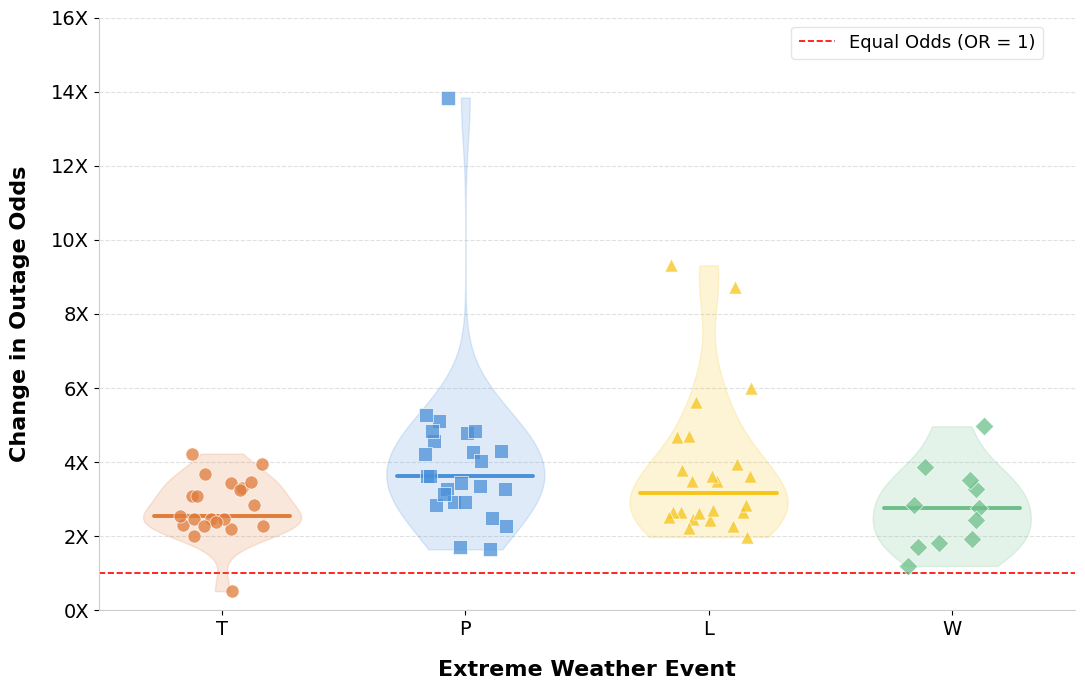

In [75]:
plot_odds_ratio_jitter(
                summary_df_clean, 
                events=['T', 'P', 'W', 'L'],
                ylim=(0, 16),
                show_legend=False,
                show_or1_line=True, 
                or1_legend_bbox=(0.7, 1),
                legend_bbox=(1.2, 1), 
                distribution_type='violin', 
                save_path=PLOTS_DIR / 'logit_outage_same_day.png'
                )

In [76]:
summary_df_clean

,ea_code9ch,event,odds_ratio
0,30200016,T,2.46
1,30200016,P,4.58
2,30200016,L,3.48
4,30200065,T,3.96
5,30200067,T,3.31
...,...,...,...
84,31300205,L,9.31
85,31300237,L,6.00
86,31300267,P,3.36
87,31300291,W,1.70


In [77]:
# len(summary_df_clean[summary_df_clean['event']=='T'])

In [78]:
# len(summary_df_clean[summary_df_clean['event']=='P'])

In [79]:
# len(summary_df_clean[summary_df_clean['event']=='L'])

In [80]:
# len(summary_df_clean[summary_df_clean['event']=='W'])

In [81]:
summary_df_clean.groupby('event')['odds_ratio'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    min='min',
    max='max',
).assign(
    IQR=lambda x: x['q75'] - x['q25'],
    range=lambda x: x['max'] - x['min'],
).round(2)

,n,mean,median,std,q25,q75,min,max,IQR,range
event,,,,,,,,,,
L,24,3.80,3.16,1.93,2.60,4.13,1.98,9.31,1.53,7.33
P,25,4.03,3.62,2.28,2.93,4.58,1.65,13.84,1.65,12.19
PL,3,9.67,12.14,8.50,6.18,14.40,0.21,16.67,8.23,16.46
T,21,2.78,2.54,0.81,2.30,3.31,0.52,4.23,1.01,3.71
W,11,2.76,2.77,1.10,1.87,3.40,1.20,4.97,1.53,3.77


In [82]:
# summary_df_clean.to_csv(DATA_DIR / 'miscellaneous/summary_df_same_day.csv')

In [83]:
summary_df_clean = summary_df_clean.merge(eas_n_cesi_level, on = 'ea_code9ch', how = 'left')

In [84]:
summary_df_clean.head()

,ea_code9ch,event,odds_ratio,cesi_level
0,30200016,T,2.46,Low
1,30200016,P,4.58,Low
2,30200016,L,3.48,Low
3,30200065,T,3.96,High
4,30200067,T,3.31,Low
